In [8]:
# from wordcloud import WordCloud, STOPWORDS
# from nltk.corpus import stopwords
import nltk
from nltk.corpus import stopwords
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')


In [9]:
movies = pd.read_csv('./tmdb_5000_movies.csv')
credits = pd.read_csv('./tmdb_5000_credits.csv')

In [10]:
movies.shape

(4803, 20)

In [11]:
movies.head(4)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [7]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


In [6]:
print(movies['genres'][1])
print(type(movies['genres'][1]).__name__)

[{"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 28, "name": "Action"}]
str


In [7]:
movies['title'][1]

"Pirates of the Caribbean: At World's End"

In [8]:
movies['tagline'][2]

'A Plan No One Escapes'

In [9]:
movies['keywords'][2]

'[{"id": 470, "name": "spy"}, {"id": 818, "name": "based on novel"}, {"id": 4289, "name": "secret agent"}, {"id": 9663, "name": "sequel"}, {"id": 14555, "name": "mi6"}, {"id": 156095, "name": "british secret service"}, {"id": 158431, "name": "united kingdom"}]'

In [12]:
print(credits['crew'][0])
print(type(credits['crew'][0]).__name__)

[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"}, 

In [11]:
print(credits['cast'][0])
print(type(credits['cast'][0]).__name__)

[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 2

In [13]:
# converting the json data to string in genres column:


movies['genres'] = movies['genres'].apply(json.loads)
for index,i in zip(movies.index,movies['genres']):
    list1 = []
    for j in range(len(i)):
        list1.append((i[j]['name'])) # the key 'name' contains the name of the genre
    movies.loc[index,'genres'] = str(list1)


print(movies['genres'])
print(type(movies['genres'][1]).__name__)

0       ['Action', 'Adventure', 'Fantasy', 'Science Fi...
1                      ['Adventure', 'Fantasy', 'Action']
2                        ['Action', 'Adventure', 'Crime']
3                ['Action', 'Crime', 'Drama', 'Thriller']
4              ['Action', 'Adventure', 'Science Fiction']
                              ...                        
4798                      ['Action', 'Crime', 'Thriller']
4799                                ['Comedy', 'Romance']
4800           ['Comedy', 'Drama', 'Romance', 'TV Movie']
4801                                                   []
4802                                      ['Documentary']
Name: genres, Length: 4803, dtype: object
str


In [15]:
print(type(movies['keywords']))
print(type(movies['production_companies']))
print(type(credits['cast']))
print(type(credits['crew']))


print(type(movies['keywords'][1]))
print(type(movies['production_companies'][1]))
print(type(credits['cast'][1]))
print(type(credits['crew'][1]))
print(type(movies['genres'][1]))


<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [16]:
# changing the keywords column from json to string
movies['keywords'] = movies['keywords'].apply(json.loads)
for index,i in zip(movies.index,movies['keywords']):
    list1 = []
    for j in range(len(i)):
        list1.append((i[j]['name']))
    movies.loc[index,'keywords'] = str(list1)

# changing the production_companies column from json to string
movies['production_companies'] = movies['production_companies'].apply(json.loads)
for index,i in zip(movies.index,movies['production_companies']):
    list1 = []
    for j in range(len(i)):
        list1.append((i[j]['name']))
    movies.loc[index,'production_companies'] = str(list1)

# changing the cast column from json to string
credits['cast'] = credits['cast'].apply(json.loads)
for index,i in zip(credits.index,credits['cast']):
    list1 = []
    for j in range(len(i)):
        list1.append((i[j]['name']))
    credits.loc[index,'cast'] = str(list1)

# changing the crew column from json to string
credits['crew'] = credits['crew'].apply(json.loads)
def director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']
credits['crew'] = credits['crew'].apply(director)

# Renaming the 'crew' column to 'director'
credits.rename(columns={'crew':'director'},inplace=True)

In [17]:
print(type(movies['keywords']))
print(type(movies['production_companies']))
print(type(credits['cast']))
print(type(credits['director']))


print(type(movies['keywords'][1]))
print(type(movies['production_companies'][1]))
print(type(credits['cast'][1]))
print(type(credits['director'][1]))
print(type(movies['genres'][1]))


<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [18]:
credits.head(3)

,movie_id,title,cast,director
0,19995,Avatar,"['Sam Worthington', 'Zoe Saldana', 'Sigourney ...",James Cameron
1,285,Pirates of the Caribbean: At World's End,"['Johnny Depp', 'Orlando Bloom', 'Keira Knight...",Gore Verbinski
2,206647,Spectre,"['Daniel Craig', 'Christoph Waltz', 'Léa Seydo...",Sam Mendes


In [19]:
movies = movies.merge(credits,left_on='id',right_on='movie_id',how='left')

In [20]:
print(movies.head(2))

# Currently has 20 columns

      budget                                             genres  \
0  237000000  ['Action', 'Adventure', 'Fantasy', 'Science Fi...   
1  300000000                 ['Adventure', 'Fantasy', 'Action']   

                                       homepage     id  \
0                   http://www.avatarmovie.com/  19995   
1  http://disney.go.com/disneypictures/pirates/    285   

                                            keywords original_language  \
0  ['culture clash', 'future', 'space war', 'spac...                en   
1  ['ocean', 'drug abuse', 'exotic island', 'east...                en   

                             original_title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   

                                            overview  popularity  \
0  In the 22nd century, a paraplegic Marine is di...  150.437577   
1  Captain Barbossa, long believed to be dead, ha...  139.082615   

                                production_companies 

In [21]:
# Now keeping only some selected columns for further process
movies = movies[['id','original_title','genres','cast','vote_average','director','keywords']]
movies.iloc[25]

id                                                              597
original_title                                              Titanic
genres                             ['Drama', 'Romance', 'Thriller']
cast              ['Kate Winslet', 'Leonardo DiCaprio', 'Frances...
vote_average                                                    7.5
director                                              James Cameron
keywords          ['shipwreck', 'iceberg', 'ship', 'panic', 'tit...
Name: 25, dtype: object

#Working with Genres Column

In [22]:
movies['genres'][25]
# Originally the 'generes' column looks like this:

"['Drama', 'Romance', 'Thriller']"

In [21]:
print(type(movies['genres'][1]).__name__)

str


In [23]:
# Cleaning the 'generes' column of movies :
# The overall effect of this line is to clean up the 'genres' column by removing:
# square brackets, spaces, and single quotes.

movies['genres'] = movies['genres'].str.strip('[]').str.replace(' ','').str.replace("'",'')
movies['genres'] = movies['genres'].str.split(',')

In [24]:
print(movies['genres'][25])
print(type(movies['genres'][1]).__name__)

['Drama', 'Romance', 'Thriller']
list


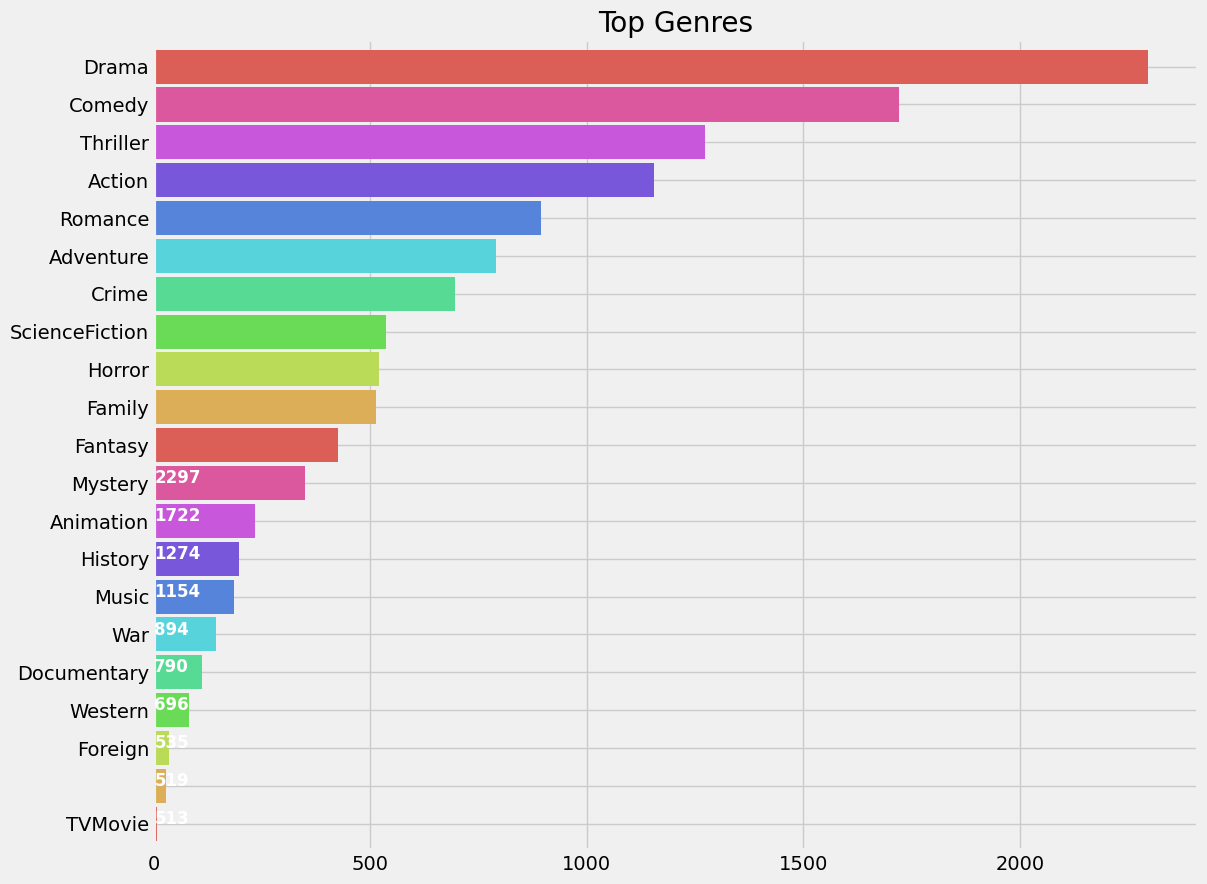

In [25]:
# Plottig graph according to the frequency of the different genres

plt.subplots(figsize=(12,10))
list1 = []
for i in movies['genres']:
    list1.extend(i)
ax = pd.Series(list1).value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('hls',10))
for i, v in enumerate(pd.Series(list1).value_counts()[:10].sort_values(ascending=True).values):
    ax.text(.8, i, v,fontsize=12,color='white',weight='bold')
plt.title('Top Genres')
plt.show()

In [26]:
# All the unique frequencies in the 'genres' column of movies

list_genres_all_frequencies = pd.Series(list1).value_counts().sort_values(ascending=True)
print(list_genres_all_frequencies)
print('total no of all genres types: ',len(list_genres_all_frequencies))

TVMovie              8
                    28
Foreign             34
Western             82
Documentary        110
War                144
Music              185
History            197
Animation          234
Mystery            348
Fantasy            424
Family             513
Horror             519
ScienceFiction     535
Crime              696
Adventure          790
Romance            894
Action            1154
Thriller          1274
Comedy            1722
Drama             2297
Name: count, dtype: int64
total no of all genres types:  21


In [27]:

# Display the original DataFrame
print("Original DataFrame:")
print(movies.head(1))

# Remove empty strings from lists in the 'genres' column
movies['genres'] = movies['genres'].apply(lambda x: [genre for genre in x if genre != ''])

# Display the DataFrame after removing empty strings
print("\nDataFrame after removing empty strings:")
print(movies.head(1))


Original DataFrame:
      id original_title                                        genres  \
0  19995         Avatar  [Action, Adventure, Fantasy, ScienceFiction]   

                                                cast  vote_average  \
0  ['Sam Worthington', 'Zoe Saldana', 'Sigourney ...           7.2   

        director                                           keywords  
0  James Cameron  ['culture clash', 'future', 'space war', 'spac...  

DataFrame after removing empty strings:
      id original_title                                        genres  \
0  19995         Avatar  [Action, Adventure, Fantasy, ScienceFiction]   

                                                cast  vote_average  \
0  ['Sam Worthington', 'Zoe Saldana', 'Sigourney ...           7.2   

        director                                           keywords  
0  James Cameron  ['culture clash', 'future', 'space war', 'spac...  


In [28]:
# Filter out rows where the size of 'genres' list is zero
movies = movies[movies['genres'].apply(len) > 0]

# Display the DataFrame after removing empty strings and rows with zero-sized lists
print("\nDataFrame after removing empty strings and rows with zero-sized lists:")
print(movies.head(2))


DataFrame after removing empty strings and rows with zero-sized lists:
      id                            original_title  \
0  19995                                    Avatar   
1    285  Pirates of the Caribbean: At World's End   

                                         genres  \
0  [Action, Adventure, Fantasy, ScienceFiction]   
1                  [Adventure, Fantasy, Action]   

                                                cast  vote_average  \
0  ['Sam Worthington', 'Zoe Saldana', 'Sigourney ...           7.2   
1  ['Johnny Depp', 'Orlando Bloom', 'Keira Knight...           6.9   

         director                                           keywords  
0   James Cameron  ['culture clash', 'future', 'space war', 'spac...  
1  Gore Verbinski  ['ocean', 'drug abuse', 'exotic island', 'east...  


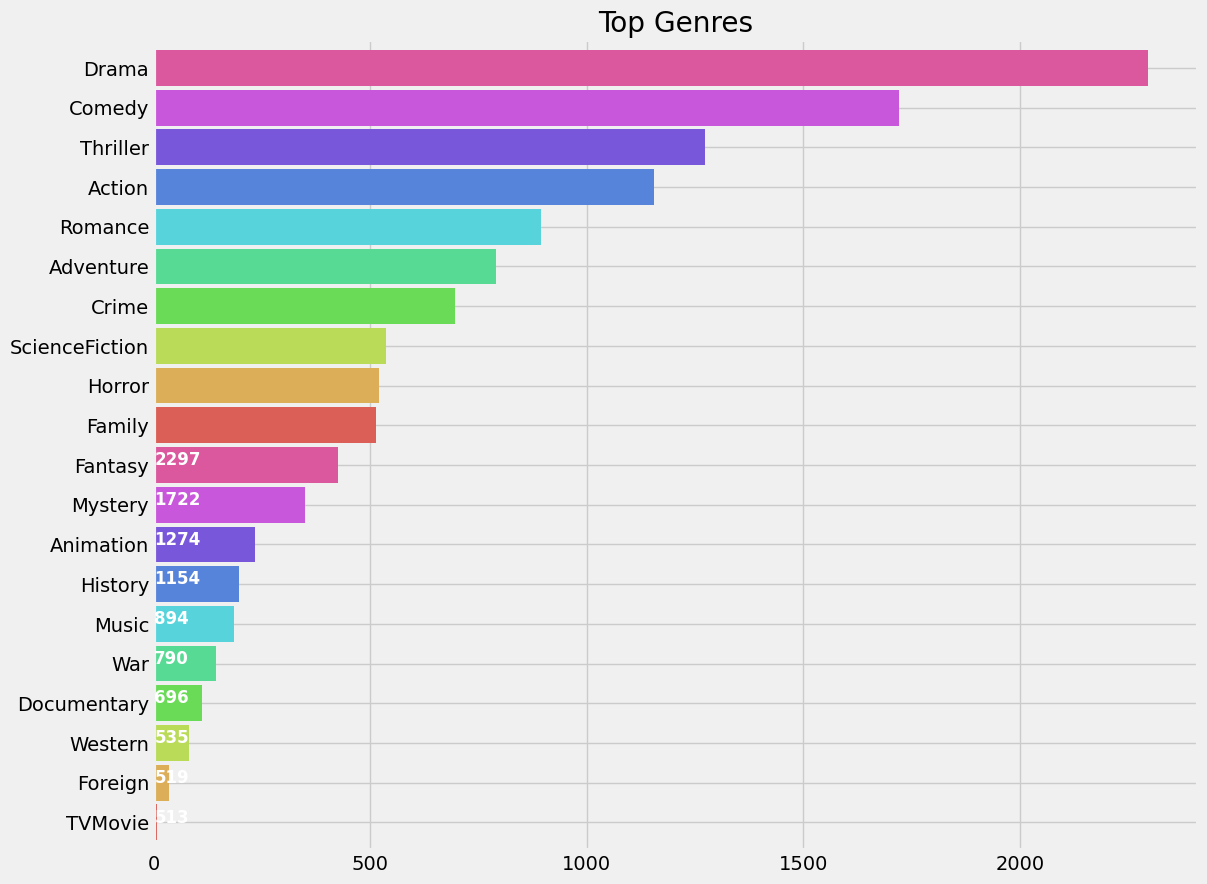

In [29]:
# Plottig graph according to the frequency of the different genres again after removing the 'empty data strings

plt.subplots(figsize=(12,10))
list1 = []
for i in movies['genres']:
    list1.extend(i)
ax = pd.Series(list1).value_counts().sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('hls',10))
for i, v in enumerate(pd.Series(list1).value_counts()[:10].sort_values(ascending=True).values):
    ax.text(.8, i, v,fontsize=12,color='white',weight='bold')
plt.title('Top Genres')
plt.show()

In [30]:
# sorting the 'genres':
for i,j in zip(movies['genres'],movies.index):
    list2=[]
    list2=i
    list2.sort()
    movies.loc[j,'genres']=str(list2)



In [31]:
# Cleaning the 'genres' column
movies['genres'] = movies['genres'].str.strip('[]').str.replace(' ','').str.replace("'",'')
movies['genres'] = movies['genres'].str.split(',')

In [32]:
print(movies['genres'])
print('\n',type(movies['genres'][1]))

0       [Action, Adventure, Fantasy, ScienceFiction]
1                       [Action, Adventure, Fantasy]
2                         [Action, Adventure, Crime]
3                   [Action, Crime, Drama, Thriller]
4                [Action, Adventure, ScienceFiction]
                            ...                     
4797                             [Foreign, Thriller]
4798                       [Action, Crime, Thriller]
4799                               [Comedy, Romance]
4800               [Comedy, Drama, Romance, TVMovie]
4802                                   [Documentary]
Name: genres, Length: 4775, dtype: object

 <class 'list'>


In [33]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4775 entries, 0 to 4802
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              4775 non-null   int64  
 1   original_title  4775 non-null   object 
 2   genres          4775 non-null   object 
 3   cast            4775 non-null   object 
 4   vote_average    4775 non-null   float64
 5   director        4759 non-null   object 
 6   keywords        4775 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 427.5+ KB


In [34]:
# Exctracting the unique genres from the all over generes column and storing in
# genreList:

genreList = []
for index, row in movies.iterrows():
    genres = row["genres"]
    for genre in genres:
        if genre not in genreList:
            genreList.append(genre)
genreList[:10] # now we have a list with unique genres

['Action',
 'Adventure',
 'Fantasy',
 'ScienceFiction',
 'Crime',
 'Drama',
 'Thriller',
 'Animation',
 'Family',
 'Western']

In [34]:
print(genreList)

['Action', 'Adventure', 'Fantasy', 'ScienceFiction', 'Crime', 'Drama', 'Thriller', 'Animation', 'Family', 'Western', 'Comedy', 'Romance', 'Horror', 'Mystery', 'History', 'War', 'Music', 'Documentary', 'Foreign', 'TVMovie']


In [35]:
# One Hot Encoding for multiple labels
def binary(genre_list):
    binaryList = []

    for genre in genreList:
        if genre in genre_list:
            binaryList.append(1)
        else:
            binaryList.append(0)

    return binaryList

In [36]:
# we have created unique genres from the dataset
# Now we are creating matrix for each movie row which has either 1 or 0
# If that "movie row" has the 'genre' present in the global genresList then 1 else 0

movies['genres_bin'] = movies['genres'].apply(lambda x: binary(x))
movies['genres_bin'].head()

0    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2    [1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3    [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...
4    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: genres_bin, dtype: object

In [37]:
print(credits['cast'][2])

['Daniel Craig', 'Christoph Waltz', 'Léa Seydoux', 'Ralph Fiennes', 'Monica Bellucci', 'Ben Whishaw', 'Naomie Harris', 'Dave Bautista', 'Andrew Scott', 'Rory Kinnear', 'Jesper Christensen', 'Alessandro Cremona', 'Stephanie Sigman', 'Tenoch Huerta', 'Adriana Paz', 'Domenico Fortunato', 'Marco Zingaro', 'Stefano Elfi DiClaudia', 'Ian Bonar', 'Tam Williams', 'Richard Banham', 'Pip Carter', 'Simon Lenagan', 'Alessandro Bressanello', 'Marc Zinga', 'Brigitte Millar', 'Adel Bencherif', 'Gediminas Adomaitis', 'Peppe Lanzetta', 'Francesco Arca', 'Matteo Taranto', 'Emilio Aniba', 'Benito Sagredo', 'Dai Tabuchi', 'George Lasha', 'Sargon Yelda', 'Andy Cheung', 'Erick Hayden', 'Oleg Mirochnikov', 'Antonio Salines', 'Miloud Mourad Benamara', 'Gido Schimanski', 'Nigel Barber', 'Patrice Naiambana', 'Stephane Cornicard', 'Gary Fannin', 'Sadao Ueda', 'Phillip Law', 'Wai Wong', 'Joseph Balderrama', 'Eiji Mihara', 'Junichi Kajioka', 'Victor Schefé', 'Harald Windisch', 'Tristan Matthiae', 'Detlef Bothe', '

In [38]:
print(type(credits['cast'][2]))

<class 'str'>


In [39]:
print(type(movies['cast'][2]))

<class 'str'>


#Working with the Cast column

In [37]:
movies['cast'] = movies['cast'].str.strip('[]')

In [38]:
movies['cast'] = movies['cast'].str.replace(' ','').str.replace("'",'').str.replace('"','')
movies['cast'] = movies['cast'].str.split(',')

In [39]:
print(type(movies['cast'][2]))

<class 'list'>


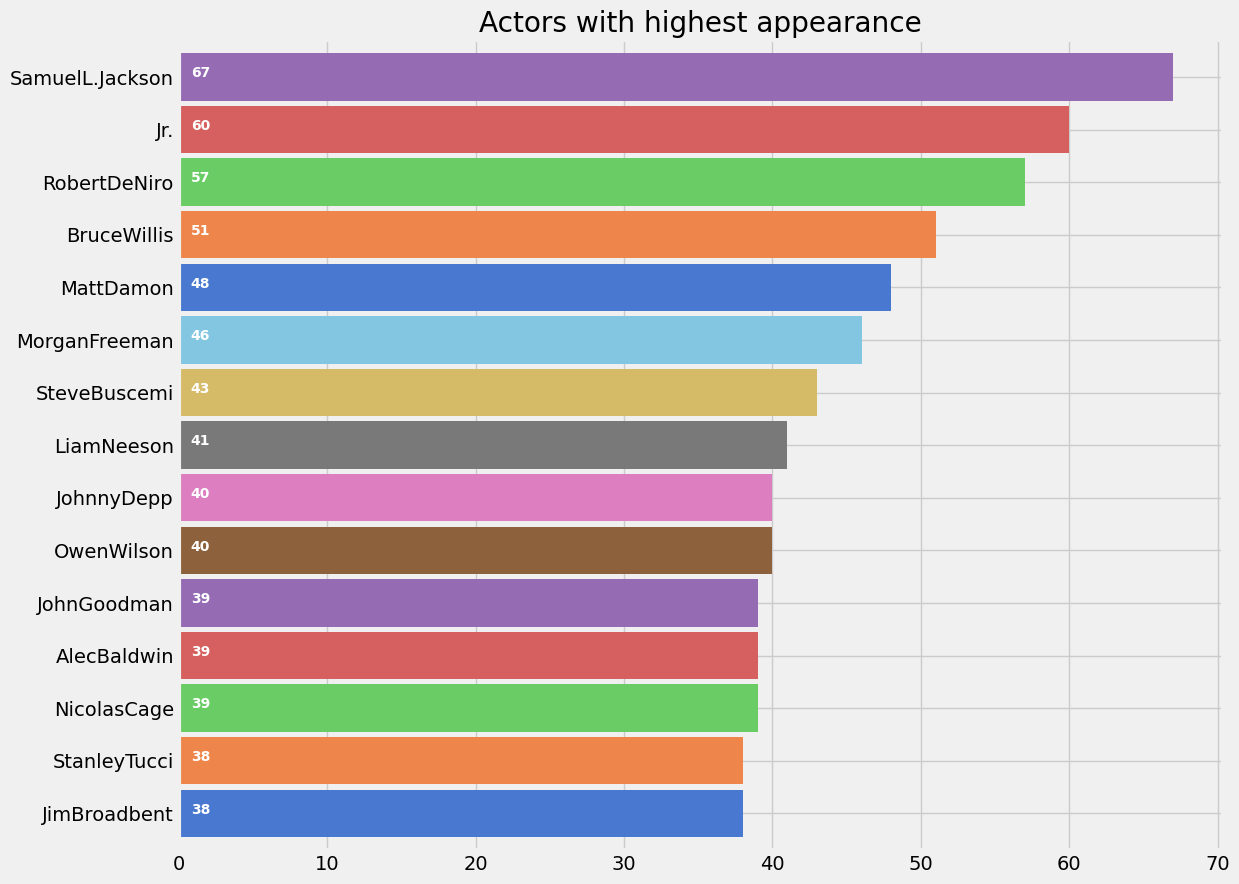

In [40]:
plt.subplots(figsize=(12,10))
list1=[]
for i in movies['cast']:
    list1.extend(i)
ax=pd.Series(list1).value_counts()[:15].sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('muted',40))
for i, v in enumerate(pd.Series(list1).value_counts()[:15].sort_values(ascending=True).values):
    ax.text(.8, i, v,fontsize=10,color='white',weight='bold')
plt.title('Actors with highest appearance')
plt.show()

In [41]:
for i,j in zip(movies['cast'],movies.index):
    list2 = []
    list2 = i[:4]
    movies.loc[j,'cast'] = str(list2)
movies['cast'] = movies['cast'].str.strip('[]').str.replace(' ','').str.replace("'",'')
movies['cast'] = movies['cast'].str.split(',')
for i,j in zip(movies['cast'],movies.index):
    list2 = []
    list2 = i
    list2.sort()
    movies.loc[j,'cast'] = str(list2)
movies['cast']=movies['cast'].str.strip('[]').str.replace(' ','').str.replace("'",'')

In [42]:
movies['cast'] = movies['cast'].str.split(',')

In [43]:
print(movies['cast'][1])

['JohnnyDepp', 'KeiraKnightley', 'OrlandoBloom', 'StellanSkarsgård']


In [47]:
print(type(movies['cast'][1]))

<class 'list'>


In [44]:
# Extracting the unique cast form the cast column

castList = []
for index, row in movies.iterrows():
    cast = row["cast"]

    for i in cast:
        if i not in castList:
            castList.append(i)

In [45]:
# Binary encoding for cast column

def binary(cast_list):
    binaryList = []

    for genre in castList:
        if genre in cast_list:
            binaryList.append(1)
        else:
            binaryList.append(0)

    return binaryList

In [46]:
movies['cast_bin'] = movies['cast'].apply(lambda x: binary(x))
movies['cast_bin'].head()

0    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...
2    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...
3    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...
4    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: cast_bin, dtype: object

In [53]:
print(castList)

['SamWorthington', 'SigourneyWeaver', 'StephenLang', 'ZoeSaldana', 'JohnnyDepp', 'KeiraKnightley', 'OrlandoBloom', 'StellanSkarsgård', 'ChristophWaltz', 'DanielCraig', 'LéaSeydoux', 'RalphFiennes', 'AnneHathaway', 'ChristianBale', 'GaryOldman', 'MichaelCaine', 'LynnCollins', 'SamanthaMorton', 'TaylorKitsch', 'WillemDafoe', 'JamesFranco', 'KirstenDunst', 'ThomasHadenChurch', 'TobeyMaguire', 'DonnaMurphy', 'MandyMoore', 'RonPerlman', 'ZacharyLevi', 'ChrisEvans', 'ChrisHemsworth', 'MarkRuffalo', 'RobertDowneyJr.', 'DanielRadcliffe', 'EmmaWatson', 'RupertGrint', 'TomFelton', 'AmyAdams', 'BenAffleck', 'GalGadot', 'HenryCavill', 'BrandonRouth', 'JamesMarsden', 'KateBosworth', 'KevinSpacey', 'JudiDench', 'MathieuAmalric', 'OlgaKurylenko', 'ArmieHammer', 'HelenaBonhamCarter', 'WilliamFichtner', 'KevinCostner', 'MichaelShannon', 'AnnaPopplewell', 'BenBarnes', 'SkandarKeynes', 'WilliamMoseley', 'IanMcShane', 'KevinMcNally', 'PenélopeCruz', 'JoshBrolin', 'MichaelStuhlbarg', 'TommyLeeJones', 'Will

#WWorking with Director Column

In [54]:
print(movies['director'].eq('').sum())

0


In [55]:
movies['director'].head(6)

0        James Cameron
1       Gore Verbinski
2           Sam Mendes
3    Christopher Nolan
4       Andrew Stanton
5            Sam Raimi
Name: director, dtype: object

In [56]:
type(movies['director']).__name__

'Series'

In [57]:
type(movies['director'][2]).__name__

'str'

In [47]:
# In summary, the code is ensuring that the 'director' column in the 'movies' DataFrame contains only string values.
# If any values are missing (None), they are replaced with an empty string, and the rest are converted to strings.
def xstr(s):
    if s is None:
        return ''
    return str(s)
movies['director'] = movies['director'].apply(xstr)

In [59]:
print(movies['director'])

0           James Cameron
1          Gore Verbinski
2              Sam Mendes
3       Christopher Nolan
4          Andrew Stanton
              ...        
4797     Neill Dela Llana
4798     Robert Rodriguez
4799         Edward Burns
4800          Scott Smith
4802     Brian Herzlinger
Name: director, Length: 4775, dtype: object


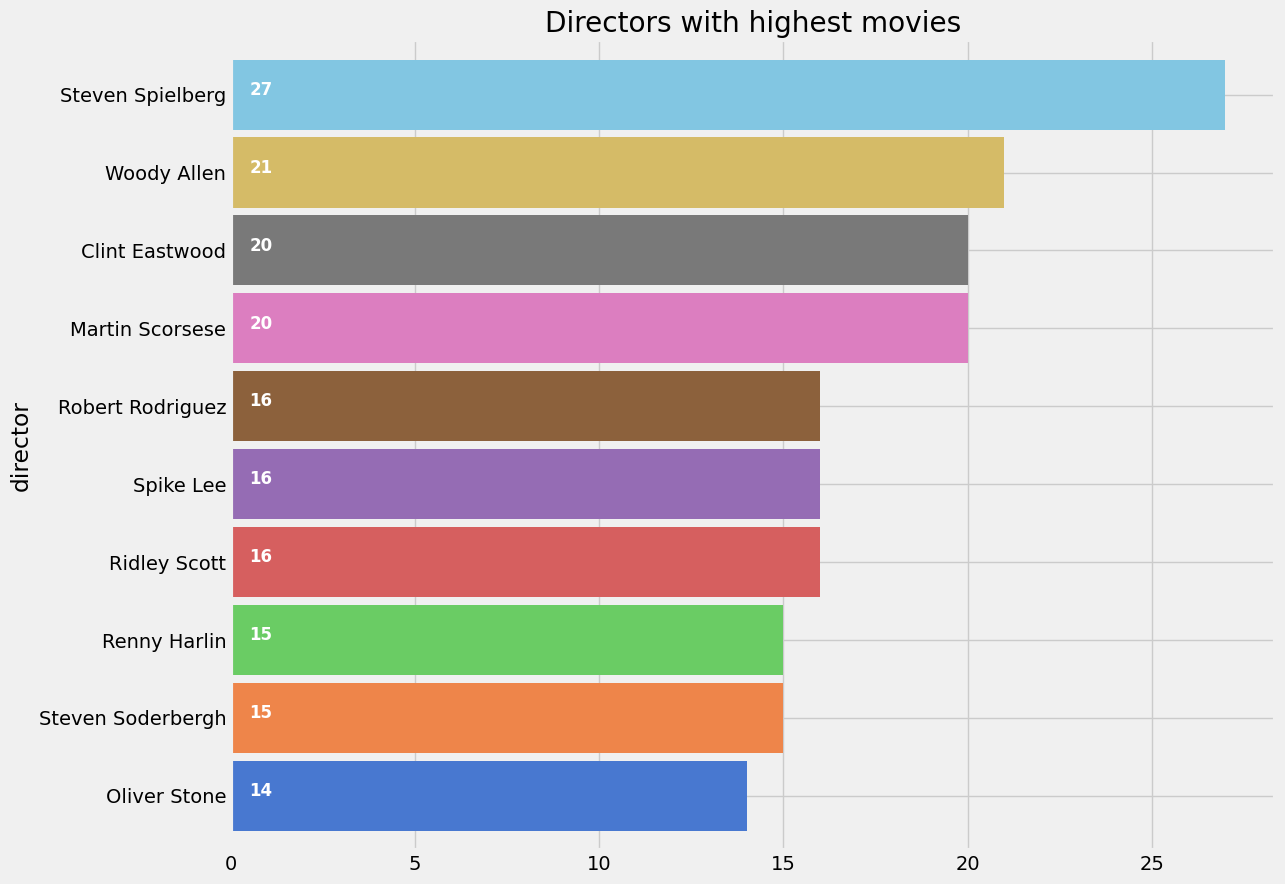

In [48]:
plt.subplots(figsize=(12,10))
ax = movies[movies['director']!=''].director.value_counts()[:10].sort_values(ascending=True).plot.barh(width=0.9,color=sns.color_palette('muted',40))
for i, v in enumerate(movies[movies['director']!=''].director.value_counts()[:10].sort_values(ascending=True).values):
    ax.text(.5, i, v,fontsize=12,color='white',weight='bold')
plt.title('Directors with highest movies')
plt.show()

In [49]:
# Exctracting unique directors

directorList=[]
for i in movies['director']:
    if i not in directorList:
        directorList.append(i)

In [50]:
# Binary Encoding for Director column

def binary(director_list):
    binaryList = []
    for direct in directorList:
        if direct in director_list:
            binaryList.append(1)
        else:
            binaryList.append(0)
    return binaryList

In [51]:
movies['director_bin'] = movies['director'].apply(lambda x: binary(x))
movies.head()

,id,original_title,genres,cast,vote_average,director,keywords,genres_bin,cast_bin,director_bin
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]","[SamWorthington, SigourneyWeaver, StephenLang,...",7.2,James Cameron,"['culture clash', 'future', 'space war', 'spac...","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,285,Pirates of the Caribbean: At World's End,"[Action, Adventure, Fantasy]","[JohnnyDepp, KeiraKnightley, OrlandoBloom, Ste...",6.9,Gore Verbinski,"['ocean', 'drug abuse', 'exotic island', 'east...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,206647,Spectre,"[Action, Adventure, Crime]","[ChristophWaltz, DanielCraig, LéaSeydoux, Ralp...",6.3,Sam Mendes,"['spy', 'based on novel', 'secret agent', 'seq...","[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[AnneHathaway, ChristianBale, GaryOldman, Mich...",7.6,Christopher Nolan,"['dc comics', 'crime fighter', 'terrorist', 's...","[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,49529,John Carter,"[Action, Adventure, ScienceFiction]","[LynnCollins, SamanthaMorton, TaylorKitsch, Wi...",6.1,Andrew Stanton,"['based on novel', 'mars', 'medallion', 'space...","[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [52]:
movies['director_bin']

0       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
                              ...                        
4797    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4798    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4799    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4800    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4802    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: director_bin, Length: 4775, dtype: object

#Working with Keywords Column

In [53]:
nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error [WinError 10061]
[nltk_data]     No connection could be made because the target machine
[nltk_data]     actively refused it>


False

In [54]:
stop_words = set(stopwords.words('english'))
stop_words.update(',',';','!','?','.','(',')','$','#','+',':','...',' ','')

In [55]:
print(stop_words)

{"didn't", 'it', 'such', "haven't", 'doing', '.', 'our', 'wouldn', 'll', 'those', 'after', 'itself', 'had', 'be', 'yours', 'weren', "mightn't", "hasn't", 'don', 'as', "wasn't", 'than', 'an', 'just', 'ma', 'for', 'was', 'they', 'now', '(', ')', 'by', 'ours', "won't", 'out', 'is', 'them', 'in', '?', "wouldn't", 'hers', 'mightn', 'are', 'all', 'y', 'nor', 'he', 'of', "isn't", 'same', 'that', 'then', 'against', 'or', 't', 'how', 'when', 'too', 'themselves', "don't", "aren't", 'did', 'who', "needn't", 'your', 'this', ' ', 'because', 'under', 'we', 'have', 'd', 'didn', 'before', "it's", 'through', 'were', 'if', 'her', 'which', 'until', "she's", 'i', 'on', 's', 'very', 'so', '!', 'during', 'once', 'its', 'whom', 'only', 'again', "mustn't", 'will', 'me', 'other', 'some', 'needn', 'up', 'does', 'more', 'my', "doesn't", 'being', "shan't", 'at', 'yourselves', "couldn't", 'theirs', "should've", 'to', 'do', 'about', 'myself', 'you', 'been', 'and', 'no', 'ain', 'while', 'isn', 'between', 'm', 'hadn'

In [56]:
nltk.download('punkt')


[nltk_data] Error loading punkt: <urlopen error [WinError 10061] No
[nltk_data]     connection could be made because the target machine
[nltk_data]     actively refused it>


False

In [57]:
words=movies['keywords'].dropna().apply(nltk.word_tokenize)
word=[]
for i in words:
    word.extend(i)
word=pd.Series(word)
word=([i for i in word.str.lower() if i not in stop_words])

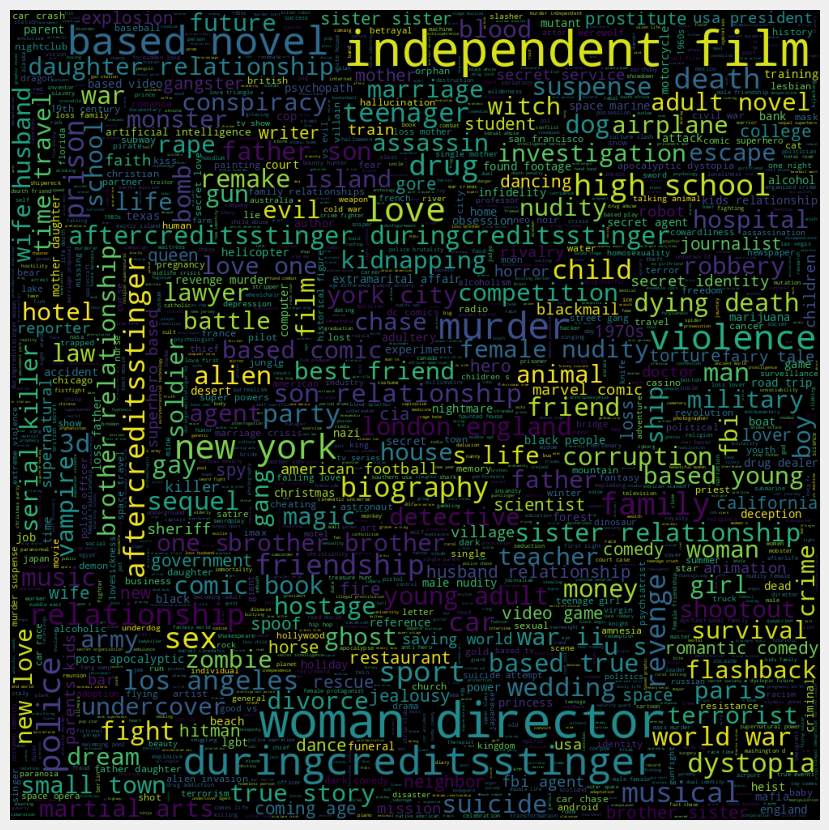

In [ ]:

# wc = WordCloud(background_color="black", max_words=2000, stopwords=STOPWORDS, max_font_size= 60,width=1000,height=1000)
# wc.generate(" ".join(word))
# plt.imshow(wc)
# plt.axis('off')
# fig=plt.gcf()
# fig.set_size_inches(10,10)
# plt.show()

In [58]:
movies['keywords'] = movies['keywords'].str.strip('[]').str.replace(' ','').str.replace("'",'').str.replace('"','')
movies['keywords'] = movies['keywords'].str.split(',')
for i,j in zip(movies['keywords'],movies.index):
    list2 = []
    list2 = i
    movies.loc[j,'keywords'] = str(list2)
movies['keywords'] = movies['keywords'].str.strip('[]').str.replace(' ','').str.replace("'",'')
movies['keywords'] = movies['keywords'].str.split(',')
for i,j in zip(movies['keywords'],movies.index):
    list2 = []
    list2 = i
    list2.sort()
    movies.loc[j,'keywords'] = str(list2)
movies['keywords'] = movies['keywords'].str.strip('[]').str.replace(' ','').str.replace("'",'')
movies['keywords'] = movies['keywords'].str.split(',')

In [71]:
print(movies['keywords'])


0       [3d, alien, alienplanet, antiwar, battle, cgi,...
1       [aftercreditsstinger, afterlife, alliance, cal...
2       [basedonnovel, britishsecretservice, mi6, secr...
3       [batman, burglar, catburglar, catwoman, cover-...
4       [19thcentury, 3d, alien, alienrace, basedonnov...
                              ...                        
4797                                                   []
4798    [arms, guitarcase, legs, paperknife, unitedsta...
4799                                                   []
4800    [date, investigation, loveatfirstsight, narrat...
4802             [camcorder, crush, dreamgirl, obsession]
Name: keywords, Length: 4775, dtype: object


In [72]:
type(movies['keywords'][1])

list

In [73]:
type(movies['keywords'][1][2])

str

In [59]:
# Extracting unique 'keywords' from the column into words_list[]

words_list = []
for index, row in movies.iterrows():
    genres = row["keywords"]

    for genre in genres:
        if genre not in words_list:
            words_list.append(genre)

In [75]:
type(words_list)

list

In [60]:
def binary(words):
    binaryList = []
    for genre in words_list:
        if genre in words:
            binaryList.append(1)
        else:
            binaryList.append(0)
    return binaryList

In [61]:
movies['words_bin'] = movies['keywords'].apply(lambda x: binary(x))
movies = movies[(movies['vote_average']!=0)] #removing the movies with 0 score and without director names
movies = movies[movies['director']!='']

In [62]:
movies['words_bin']

0       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...
1       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4       [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
                              ...                        
4797    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4798    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4799    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4800    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4802    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: words_bin, Length: 4715, dtype: object

# Similarity

In [63]:
from scipy import spatial

# Cosine Distance calculator function on three attributes: 'genres', 'score' and 'words'

def Similarity(movieId1, movieId2):
    a = movies.iloc[movieId1]
    b = movies.iloc[movieId2]

    genresA = a['genres_bin']
    genresB = b['genres_bin']

    genreDistance = spatial.distance.cosine(genresA, genresB)
    scoreA = a['cast_bin']
    scoreB = b['cast_bin']
    scoreDistance = spatial.distance.cosine(scoreA, scoreB)

    directA = a['director_bin']
    directB = b['director_bin']
    directDistance = spatial.distance.cosine(directA, directB)

    wordsA = a['words_bin']
    wordsB = b['words_bin']
    wordsDistance = spatial.distance.cosine(wordsA, wordsB)

    return genreDistance + directDistance + scoreDistance + wordsDistance

In [64]:
movies.loc[movies['id']==16]

,id,original_title,genres,cast,vote_average,director,keywords,genres_bin,cast_bin,director_bin,words_bin
2799,16,Dancer in the Dark,"[Crime, Drama, Music]","[Björk, CatherineDeneuve, DavidMorse, PeterSto...",7.6,Lars von Trier,"[blindnessandimpairedvision, crime, czech, dan...","[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [65]:
Similarity(3,160)

3.2958758547680684

In [66]:
print(movies.iloc[3])
print(movies.iloc[160])

id                                                            49026
original_title                                The Dark Knight Rises
genres                             [Action, Crime, Drama, Thriller]
cast              [AnneHathaway, ChristianBale, GaryOldman, Mich...
vote_average                                                    7.6
director                                          Christopher Nolan
keywords          [batman, burglar, catburglar, catwoman, cover-...
genres_bin        [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...
cast_bin          [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...
director_bin      [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
words_bin         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: 3, dtype: object
id                                                            82702
original_title                           How to Train Your Dragon 2
genres            [Action, Adventure, Animation, Comedy, Family,...
cast              [Gerard

In [67]:
# Indexing the dataframe

new_id = list(range(0,movies.shape[0]))
movies['new_id']=new_id
movies=movies[['original_title','genres','vote_average','genres_bin','cast_bin','new_id','director','director_bin','words_bin']]
movies.head()

,original_title,genres,vote_average,genres_bin,cast_bin,new_id,director,director_bin,words_bin
0,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]",7.2,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,James Cameron,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Pirates of the Caribbean: At World's End,"[Action, Adventure, Fantasy]",6.9,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...",1,Gore Verbinski,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Spectre,"[Action, Adventure, Crime]",6.3,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...",2,Sam Mendes,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",7.6,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...",3,Christopher Nolan,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,John Carter,"[Action, Adventure, ScienceFiction]",6.1,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4,Andrew Stanton,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [68]:
movies.shape[0]

4715

In [69]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4715 entries, 0 to 4802
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   original_title  4715 non-null   object 
 1   genres          4715 non-null   object 
 2   vote_average    4715 non-null   float64
 3   genres_bin      4715 non-null   object 
 4   cast_bin        4715 non-null   object 
 5   new_id          4715 non-null   int64  
 6   director        4715 non-null   object 
 7   director_bin    4715 non-null   object 
 8   words_bin       4715 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 368.4+ KB


# Score Predictor

In [70]:
# Modified Predic_score function:

import operator

def predict_score(movie_id):
    try:
        movie_id = int(movie_id)  # Ensure movie_id is an integer
        new_movie = movies[movies['new_id'] == movie_id].iloc[0].to_frame().T
    except IndexError:
        print(f"Movie with new_id '{movie_id}' not found.")
        return None


    def getNeighbors(baseMovie, K):
        distances = []

        for index, movie in movies.iterrows():
            if movie['new_id'] != baseMovie['new_id'].values[0]:
                dist = Similarity(baseMovie['new_id'].values[0], movie['new_id'])
                distances.append((movie['new_id'], dist))

        distances.sort(key=operator.itemgetter(1))
        neighbors = []

        for x in range(K):
            neighbors.append(distances[x])

        return neighbors

    K = 10
    avgRating = 0
    neighbors = getNeighbors(new_movie, K)

    if not neighbors:
        print(f"No neighbors found for movie with new_id '{movie_id}'.")
        return None

    for neighbor in neighbors:
        neighbor_id = neighbor[0]
        if 0 <= neighbor_id < len(movies):
            avgRating += movies.iloc[neighbor_id]['vote_average']
            print(f"{movies.iloc[neighbor_id]['original_title']} | Genres: {str(movies.iloc[neighbor_id]['genres']).strip('[]').replace(' ','')} | Rating: {movies.iloc[neighbor_id]['vote_average']}")

    avgRating /= K
    print(f'The predicted rating for movie with new_id {new_movie["original_title"].values[0]} is: {avgRating}')
    print(f'The actual rating for movie with new_id {new_movie["original_title"].values[0]} is {new_movie["vote_average"].values[0]}')

    return avgRating



In [71]:
def getMovieID(movie_title):
  movie_row = movies[movies['original_title'] == movie_title]

  if not movie_row.empty:
      movie_id = movie_row.iloc[0]['new_id']
      print(f"The movie_id for '{movie_title}' is: {movie_id}")
      return movie_id
  else:
      print(f"Movie '{movie_title}' not found in the DataFrame.")
      return None

In [72]:
predict_score(31)

Iron Man 2 | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.6
Iron Man | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.4
Captain America: Civil War | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.1
Avengers: Age of Ultron | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.3
The Avengers | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.4
Ant-Man | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.0
Captain America: The Winter Soldier | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.6
Captain America: The First Avenger | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.6
X-Men | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.8
The Incredible Hulk | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.1
The predicted rating for movie with new_id Iron Man 3 is: 6.99
The actual rating for movie with new_id Iron Man 3 is 6.8


6.99

In [73]:
def recommendME():
  movie_name = input("Enter Movie name: ")
  print('Selected movie: ',movie_name)
  movie_id = getMovieID(movie_name)
  predict_score(movie_id)

recommendME()

Selected movie:  Iron Man
The movie_id for 'Iron Man' is: 68
Iron Man 2 | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.6
Iron Man 3 | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.8
The Avengers | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.4
Captain America: Civil War | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.1
Avengers: Age of Ultron | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.3
Ant-Man | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.0
Captain America: The Winter Soldier | Genres: 'Action','Adventure','ScienceFiction' | Rating: 7.6
X-Men | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.8
Captain America: The First Avenger | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.6
The Incredible Hulk | Genres: 'Action','Adventure','ScienceFiction' | Rating: 6.1
The predicted rating for movie with new_id Iron Man is: 6.93
The actual rating for movie with new_id Iron Man is 7.4


# APP for Implementation using StreamLit

In [74]:


# Function to check if a callable (function) is a lambda function
def is_lambda_function(func):
    return callable(func) and func.__name__ == "<lambda>"

# Check if any column in the DataFrame contains a lambda function
contains_lambda = any(movies.applymap(is_lambda_function).any())

# Display the result
if contains_lambda:
    print("DataFrame contains at least one lambda function.")
else:
    print("DataFrame does not contain any lambda functions.")

DataFrame does not contain any lambda functions.


In [90]:
import pandas as pd

# Assuming 'movies' is your DataFrame
# Save the DataFrame to a pickle file
movies.to_pickle('movies_data.pkl')


In [ ]:
import pickle
pickle.dump(movies.to_dict(),open('movie_dict2.pkl','wb'))